In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as skl

In [37]:
titanic =  pd.read_csv("./Titanic-Dataset.csv", usecols=["Age", "Pclass", "Fare", "Survived"])
titanic.sample(10)

,Survived,Pclass,Age,Fare
268,1,1,58.0,153.4625
844,0,3,17.0,8.6625
551,0,2,27.0,26.0000
786,1,3,18.0,7.4958
391,1,3,21.0,7.7958
823,1,3,27.0,12.4750
136,1,1,19.0,26.2833
577,1,1,39.0,55.9000
543,1,2,32.0,26.0000
318,1,1,31.0,164.8667


In [38]:
x = titanic.iloc[::, 1::]
y = titanic.iloc[::, 0]
x

,Pclass,Age,Fare
0,3,22.0,7.2500
1,1,38.0,71.2833
2,3,26.0,7.9250
3,1,35.0,53.1000
4,3,35.0,8.0500
...,...,...,...
886,2,27.0,13.0000
887,1,19.0,30.0000
888,3,NaN,23.4500
889,1,26.0,30.0000


In [39]:
titanic.isnull().sum()

Survived      0
Pclass        0
Age         177
Fare          0
dtype: int64

In [40]:
x_train, x_test, y_train, y_test = skl.model_selection.train_test_split(x, y, test_size= 0.2, random_state= 42)

In [43]:
knnImputer = skl.impute.KNNImputer(n_neighbors= 5, weights= "distance")  # weight= "uniform"

x_train_knn = knnImputer.fit_transform(x_train)
x_test_knn = knnImputer.transform(x_test)


x_train_knn = pd.DataFrame(x_train_knn, columns= x_train.columns)
x_test_knn = pd.DataFrame(x_test_knn, columns= x_train.columns)

<Axes: ylabel='Density'>

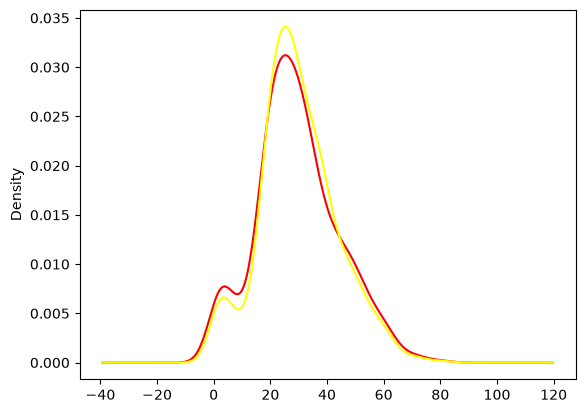

In [44]:
x_train["Age"].plot(kind= "kde", color= "red")
x_train_knn["Age"].plot(kind= "kde", color= "Yellow")

<Axes: >

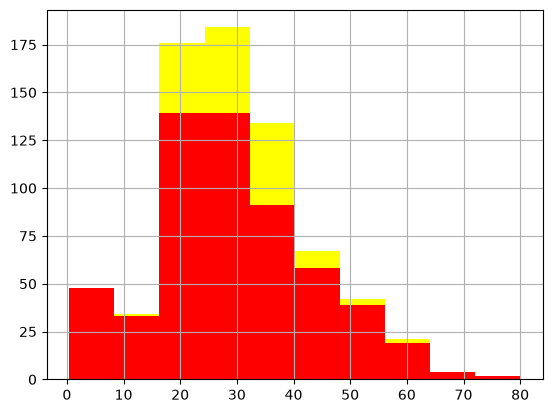

In [45]:

x_train_knn["Age"].hist(color= "yellow")
x_train["Age"].hist(color= "red")

In [46]:
lg = skl.linear_model.LogisticRegression()

lg.fit(x_train_knn, y_train)
y_pred = lg.predict(x_test_knn)

skl.metrics.accuracy_score(y_test, y_pred)

0.7374301675977654